# **Internship Project: PRCP-1013-WalkRunClass**
# **Project ID: PRCP-1013**

**Team ID**: PTID-CDS-JAN-26-3696

**Intern**: Jadhav Nilesh Sanjay

**Specialization**: AI Engineer

# **Step 1 – Business Understanding & Dataset Loading**

**Human activity recognition using wearable sensors is widely used in areas such as:**

- fitness tracking applications

- health monitoring systems

- sports analytics

- smart wearable devices

**Problem Statement**

The goal is to create a predictive model that classifies a user’s activity as:

- Walking

- Running

**Dataset Description**

The dataset contains motion sensor readings collected while users performed daily activities.

- Attributes
- date

- time

- username

- wrist

- activity (target variable)

- acceleration_x

- acceleration_y

- acceleration_z

- gyro_x

- gyro_y

- gyro_z

**Import libraries**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout


**Load the Dataset**

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
dataset = pd.read_csv('/content/drive/MyDrive/Internship_projects/PRCP-1013-WalkRunClass/Data/walkrun.csv')

**Basic Dataset Inspection**

In [4]:
dataset.head()

,date,time,username,wrist,activity,acceleration_x,acceleration_y,acceleration_z,gyro_x,gyro_y,gyro_z
0,2017-6-30,13:51:15:847724020,viktor,0,0,0.2650,-0.7814,-0.0076,-0.0590,0.0325,-2.9296
1,2017-6-30,13:51:16:246945023,viktor,0,0,0.6722,-1.1233,-0.2344,-0.1757,0.0208,0.1269
2,2017-6-30,13:51:16:446233987,viktor,0,0,0.4399,-1.4817,0.0722,-0.9105,0.1063,-2.4367
3,2017-6-30,13:51:16:646117985,viktor,0,0,0.3031,-0.8125,0.0888,0.1199,-0.4099,-2.9336
4,2017-6-30,13:51:16:846738994,viktor,0,0,0.4814,-0.9312,0.0359,0.0527,0.4379,2.4922


In [5]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 88588 entries, 0 to 88587
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   date            88588 non-null  object 
 1   time            88588 non-null  object 
 2   username        88588 non-null  object 
 3   wrist           88588 non-null  int64  
 4   activity        88588 non-null  int64  
 5   acceleration_x  88588 non-null  float64
 6   acceleration_y  88588 non-null  float64
 7   acceleration_z  88588 non-null  float64
 8   gyro_x          88588 non-null  float64
 9   gyro_y          88588 non-null  float64
 10  gyro_z          88588 non-null  float64
dtypes: float64(6), int64(2), object(3)
memory usage: 7.4+ MB


In [6]:
dataset.shape

(88588, 11)

In [7]:
dataset.isnull().sum()

,0
date,0
time,0
username,0
wrist,0
activity,0
acceleration_x,0
acceleration_y,0
acceleration_z,0
gyro_x,0
gyro_y,0


Observation-
- data contains sensor readings for walking and runing activity
- No missing values are present
- Both numerical and categorical features are exist
- activity is our target variable

**Target variable distribution**

In [8]:
dataset['activity'].value_counts()

,count
activity,
1,44365
0,44223


<Axes: xlabel='activity', ylabel='count'>

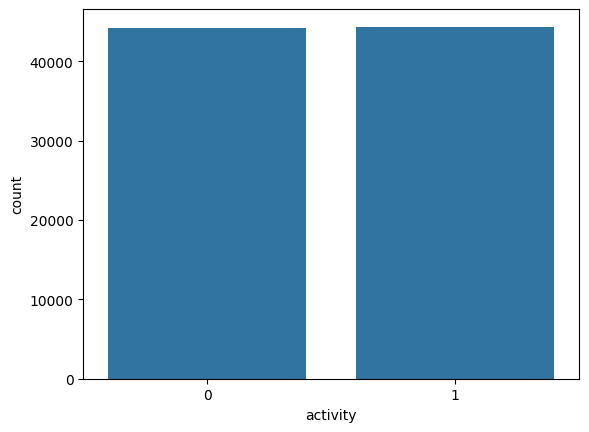

In [9]:
sns.countplot(x='activity', data=dataset)

Observation
- data is balanced

# **Step 2 – Exploratory Data Analysis (EDA)**

**Data overview**

In [10]:
dataset.describe()

,wrist,activity,acceleration_x,acceleration_y,acceleration_z,gyro_x,gyro_y,gyro_z
count,88588.000000,88588.000000,88588.000000,88588.000000,88588.000000,88588.000000,88588.000000,88588.000000
mean,0.522170,0.500801,-0.074811,-0.562585,-0.313956,0.004160,0.037203,0.022327
std,0.499511,0.500002,1.009299,0.658458,0.486815,1.253423,1.198725,1.914423
min,0.000000,0.000000,-5.350500,-3.299000,-3.753800,-4.430600,-7.464700,-9.480000
25%,0.000000,0.000000,-0.381800,-1.033500,-0.376000,-0.920700,-0.644825,-1.345125
50%,1.000000,1.000000,-0.059500,-0.759100,-0.221000,0.018700,0.039300,0.006900
75%,1.000000,1.000000,0.355500,-0.241775,-0.085900,0.888800,0.733700,1.398200
max,1.000000,1.000000,5.603300,2.668000,1.640300,4.874200,8.498000,11.266200


Observation
- sensor features have both negative and positive values
- feature scales are across dimention
- it need to be feature scaling bedore aaplying distandce bansed models and neural network

**Class Distribution Analysis**

In [11]:
dataset['activity'].value_counts()

,count
activity,
1,44365
0,44223


<Axes: xlabel='activity', ylabel='count'>

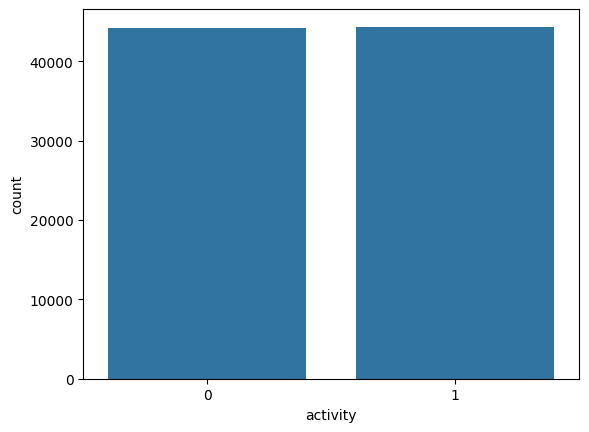

In [12]:
sns.countplot(x='activity', data=dataset)

Observation
- data contains two classes Walking and Running
- class distribution is balanced


**Correlation Analysis**

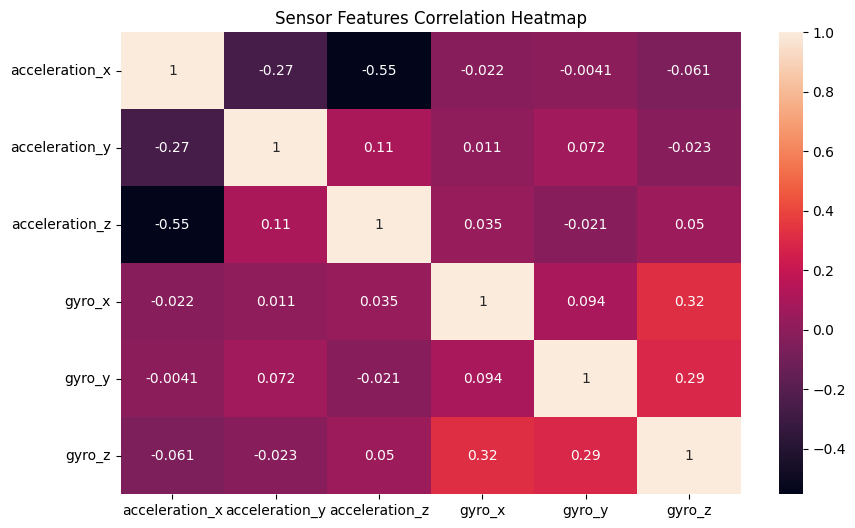

In [13]:
sensor_featues = ['acceleration_x','acceleration_y','acceleration_z']
gyro_features = ['gyro_x','gyro_y','gyro_z']

plt.figure(figsize=(10,6))
sns.heatmap(dataset[sensor_featues + gyro_features].corr(), annot=True)
plt.title('Sensor Features Correlation Heatmap')
plt.show()

Observation
- strongest relationship observed is a negative correlation (-0.55) between acceleration_x and acceleration_z
- No extreme multicollinearity is observed

**EDA-Based Challenges Identified**
- Sensor data contains noise and high variability needs a scaling
- Neural networks are suitable for capturing complex patterns
- Overfitting risk must be controlled during training

# **Step 3 – Data Cleaning & Preprocessing**

**Handling Irrelevant Columns**

- date
- time
- username

 this columns do nont contribute activity classification so we removed it

 **Reason**

Activity classification depends on sensor readings, not user identity or time

Removing these columns improves model generalization


In [14]:
dataset.drop(['date','time','username'], axis=1, inplace=True)

**Separate Features and Target**

In [15]:
x = dataset.drop('activity', axis=1)
y = dataset['activity']

**Train–Test Split**

In [16]:
x_train,x_test,y_train,y_test = train_test_split(x,y, test_size=0.2, random_state=42, stratify=y)

Reason -

stratify=y ensures both walking and running are proportionally represented

Prevents class imbalance in train or test sets

**Feature Scaling**

In [17]:
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

Sensor features have different ranges and units.
Scaling is mandatory, especially for:

- Logistic Regression

- KNN

- Artificial Neural Networks

**Conclusion**

- Irrelevant columns were removed
- Target variable was prepared
- Dataset was split correctly
- Feature scaling was applied where required

# **STEP 4 – Baseline Machine Learning Models**

## **Model 1 – Logistic Regression**

In [18]:
lr_model = LogisticRegression()
lr_model.fit(x_train_scaled, y_train)

LogisticRegression()

In [20]:
y_pred_lr = lr_model.predict(x_test_scaled)

print('accuracy score- ',accuracy_score(y_test, y_pred_lr))
print('classification report- \n',classification_report(y_test, y_pred_lr))
print('confusion matrix- \n',confusion_matrix(y_test, y_pred_lr))

accuracy score-  0.8639236934191218
classification report- 
               precision    recall  f1-score   support

           0       0.83      0.91      0.87      8845
           1       0.90      0.82      0.86      8873

    accuracy                           0.86     17718
   macro avg       0.87      0.86      0.86     17718
weighted avg       0.87      0.86      0.86     17718

confusion matrix- 
 [[8055  790]
 [1621 7252]]


**Observation**

- Logistic regression achieve 86% accuracy
- the confusion matrix show that there is missclassification two classes
- sensor data contains non-linear patterns that this model cannot capture effectively

## **Model 2 – K-Nearest Neighbors (KNN)**

In [21]:
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(x_train_scaled, y_train)

KNeighborsClassifier()

In [22]:
y_pred_knn = knn_model.predict(x_test_scaled)

print('accuracy score- ',accuracy_score(y_test, y_pred_knn))
print('classification report- \n',classification_report(y_test, y_pred_knn))
print('confusion matrix- \n',confusion_matrix(y_test, y_pred_knn))

accuracy score-  0.9913082740715656
classification report- 
               precision    recall  f1-score   support

           0       0.99      1.00      0.99      8845
           1       1.00      0.99      0.99      8873

    accuracy                           0.99     17718
   macro avg       0.99      0.99      0.99     17718
weighted avg       0.99      0.99      0.99     17718

confusion matrix- 
 [[8810   35]
 [ 119 8754]]


**Observation**
- KNN achieve 99% accuracy
- confusion matrix show very few missclassification
- KNN model well saparated two classes in cluster
- KNN performe extreamely well but it not ideal for real time

## **Baseline Model 3 – Decision Tree**

In [23]:
dt_model = DecisionTreeClassifier()
dt_model.fit(x_train, y_train)

DecisionTreeClassifier()

In [24]:
y_pred_dt = dt_model.predict(x_test)

print('accuracy score- ',accuracy_score(y_test, y_pred_dt))
print('classification report- \n',classification_report(y_test, y_pred_dt))
print('confusion matrix- \n',confusion_matrix(y_test, y_pred_dt))

accuracy score-  0.9854949768596907
classification report- 
               precision    recall  f1-score   support

           0       0.99      0.98      0.99      8845
           1       0.99      0.99      0.99      8873

    accuracy                           0.99     17718
   macro avg       0.99      0.99      0.99     17718
weighted avg       0.99      0.99      0.99     17718

confusion matrix- 
 [[8712  133]
 [ 124 8749]]


In [25]:
# overfit check
y_pred_train_dt = dt_model.predict(x_train)
print('accuracy score- ',accuracy_score(y_train, y_pred_train_dt))

accuracy score-  1.0


**Observation**

- Decision tree achieve high accuracy 98%
- confusion matrix show that there is high missclassification as compared to KNN specificaly in class 0
- also test accuracy is 100% so this indicating overfitting

## **Model 4 – Random Forest**

In [26]:
rf_model = RandomForestClassifier(n_estimators=100)
rf_model.fit(x_train, y_train)

RandomForestClassifier()

In [27]:
y_pred_rf = rf_model.predict(x_test)

print('accuracy score- ',accuracy_score(y_test, y_pred_rf))
print('classification report- \n',classification_report(y_test, y_pred_rf))
print('confusion matrix- \n',confusion_matrix(y_test, y_pred_rf))

accuracy score-  0.9918162320803703
classification report- 
               precision    recall  f1-score   support

           0       0.99      0.99      0.99      8845
           1       0.99      0.99      0.99      8873

    accuracy                           0.99     17718
   macro avg       0.99      0.99      0.99     17718
weighted avg       0.99      0.99      0.99     17718

confusion matrix- 
 [[8777   68]
 [  77 8796]]


**Observation**

- random forest achieve high accuracy 99%
- confusion matrix show that missclassification but its minimal and balanced across two classes

## **Step 4 – Overall Summary**

- Logistic regression model is underperform due to non linear sensor patterns so its not suitable for final model

- KNN, decision tree and random forest models performe best than linear model. also KNN is store entire training data so prediction is slow so this model not suitable for final model.

- High performance of non-linear models confirms the need for advanced learning methods.

- Overfitting behavior was identified in decision tree so this model is not suitable for final model.

- sensor data has complex patterns and this models either underperformance and scalibility challenges

# **Step 5 – Artificial Neural Network (ANN) Model**

**Prepare Data for ANN**
- ANN is sensitive to feature scale so we use scaled data

In [28]:
input_dim = x_train_scaled.shape[1]

**Build ANN model**

In [29]:
ann_model = Sequential()
ann_model.add(Dense(64, activation='relu', input_dim=input_dim))
ann_model.add(Dense(32, activation='relu'))
ann_model.add(Dense(1, activation='sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [30]:
ann_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [31]:
history = ann_model.fit(x_train_scaled, y_train, epochs=20, batch_size=32, validation_split=0.2, verbose=1)

Epoch 1/20
1772/1772 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - accuracy: 0.9516 - loss: 0.1535 - val_accuracy: 0.9908 - val_loss: 0.0317
Epoch 2/20
1772/1772 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9890 - loss: 0.0313 - val_accuracy: 0.9912 - val_loss: 0.0297
Epoch 3/20
1772/1772 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9903 - loss: 0.0282 - val_accuracy: 0.9920 - val_loss: 0.0257
Epoch 4/20
1772/1772 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9909 - loss: 0.0256 - val_accuracy: 0.9925 - val_loss: 0.0254
Epoch 5/20
1772/1772 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9923 - loss: 0.0216 - val_accuracy: 0.9927 - val_loss: 0.0252
Epoch 6/20
1772/1772 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9928 - loss: 0.0213 - val_accuracy: 0.9929 - val_loss: 0.0232
Epoch 7/20
1772/1772 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9927 - loss: 0.0201 - val_accuracy: 0.9924 - val_loss: 0.0250
Epoch 8/20
1772/1772 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9929 - loss: 0.0199 -

In [32]:
y_pred_ann = ann_model.predict(x_test_scaled)
y_pred_ann = (y_pred_ann > 0.5).astype(int)

print('accuracy score- ',accuracy_score(y_test, y_pred_ann))
print('classification report- \n',classification_report(y_test, y_pred_ann))
print('confusion matrix- \n',confusion_matrix(y_test, y_pred_ann))

554/554 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
accuracy score-  0.9930014674342477
classification report- 
               precision    recall  f1-score   support

           0       0.99      0.99      0.99      8845
           1       0.99      0.99      0.99      8873

    accuracy                           0.99     17718
   macro avg       0.99      0.99      0.99     17718
weighted avg       0.99      0.99      0.99     17718

confusion matrix- 
 [[8793   52]
 [  72 8801]]


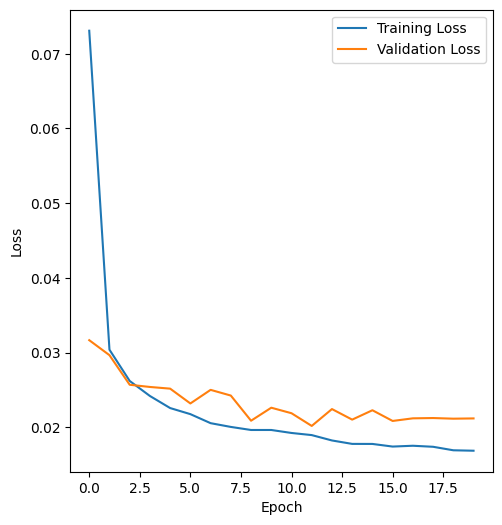

In [35]:
# Learning Curve Analysis

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

**Observation**

- ANN achieve highest accuracy 99.30% among all above models
- classification report shows that there precision, recall and f1 score is balanced and high(0.99)
- confusion matrix show that very less missclassification in two classes among all above model
- learning curv show that there is stable curves show that model learn meaningful and complex pattern not just memorizing data
- ANN is well-suited for real-world deployment in activity recognition systems.

# **Step 6 – ANN Improvement & Regularization**

- we use techniques like, dropout, early stoping

In [39]:
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

reg_ann_model = Sequential()
reg_ann_model.add(Dense(64, activation='relu', input_dim=input_dim))
reg_ann_model.add(Dropout(0.3))
reg_ann_model.add(Dense(32, activation='relu'))
reg_ann_model.add(Dropout(0.3))
reg_ann_model.add(Dense(1, activation='sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [40]:
reg_ann_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [41]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

In [43]:
history_reg = reg_ann_model.fit(x_train_scaled, y_train, epochs=50, batch_size=32, validation_split=0.2, callbacks=[early_stop], verbose=1)

Epoch 1/50
1772/1772 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9795 - loss: 0.0630 - val_accuracy: 0.9893 - val_loss: 0.0336
Epoch 2/50
1772/1772 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9845 - loss: 0.0475 - val_accuracy: 0.9915 - val_loss: 0.0296
Epoch 3/50
1772/1772 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9876 - loss: 0.0372 - val_accuracy: 0.9916 - val_loss: 0.0284
Epoch 4/50
1772/1772 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9875 - loss: 0.0371 - val_accuracy: 0.9917 - val_loss: 0.0281
Epoch 5/50
1772/1772 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9889 - loss: 0.0345 - val_accuracy: 0.9920 - val_loss: 0.0272
Epoch 6/50
1772/1772 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9890 - loss: 0.0331 - val_accuracy: 0.9923 - val_loss: 0.0265
Epoch 7/50
1772/1772 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9892 - loss: 0.0339 - val_accuracy: 0.9923 - val_loss: 0.0262
Epoch 8/50
1772/1772 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9895 - loss: 0.0321 - 

In [44]:
y_pred_reg = reg_ann_model.predict(x_test_scaled)
y_pred_reg = (y_pred_reg > 0.5).astype(int)

print('accuracy score- ',accuracy_score(y_test, y_pred_reg))
print('classification report- \n',classification_report(y_test, y_pred_reg))
print('confusion matrix- \n',confusion_matrix(y_test, y_pred_reg))

554/554 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
accuracy score-  0.9922677503104188
classification report- 
               precision    recall  f1-score   support

           0       0.99      0.99      0.99      8845
           1       0.99      0.99      0.99      8873

    accuracy                           0.99     17718
   macro avg       0.99      0.99      0.99     17718
weighted avg       0.99      0.99      0.99     17718

confusion matrix- 
 [[8771   74]
 [  63 8810]]


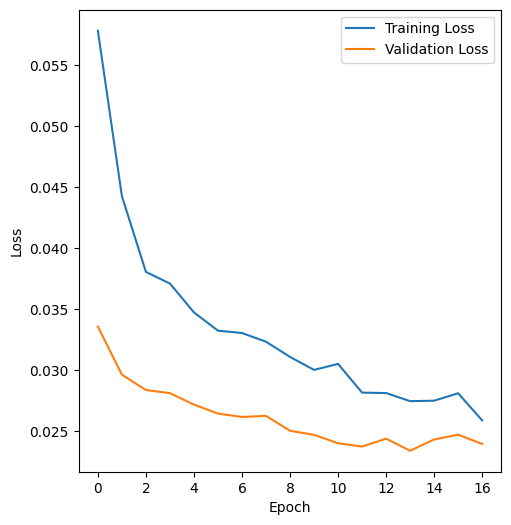

In [45]:
# learning currv analysis

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(history_reg.history['loss'], label='Training Loss')
plt.plot(history_reg.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

**Onservation**

- this model gives accuracy 99.2% which is very close to baseline ANN model
- classification report remains same
- confusion matrix show very few missclassification obeserved
- in learning curv there is no diversion in training and validation curv. it show reduce overfitting and improve generalization

# **Step 7 – Model Comparison & Final Selection**

**Model performance summery**

| Model               | Test Accuracy |
| ------------------- | ------------- |
| Logistic Regression | ~86%          |
| KNN                 | ~99.1%        |
| Decision Tree       | ~98.5%        |
| Random Forest       | ~99.2%        |
| ANN (Baseline)      | ~99.3%        |
| ANN (Regularized)   | ~99.2%        |


**Final model selection**

# Final Selected Model: **Regularized Artificial Neural Network (ANN)**

- it aachieve 99.2% accuracy
- show stable learning behavior
- handles complex patterns
- suitable for realword deploy

# **Step 8 – Challenges Faced**

**1-Sensor Data Noise**

- the data of motion sensor contains sudden spikes due to rapid movement

**solution**
- outliers found in data but we cant remove it cause it remove informative data

**2-Non-linear Activity Patterns**

- non linear patterns of walking and running are overlapping motions
- linear model failed to capture this pattern

**solution**
- so we used advanced non linear models such as ANN

**3-Overfitting Risk in Complex Models**

- Decision tree and unregularized ANN show sign of overfittig

**solution**
- so we use regularized techniques like dropout, early stopping

**4-Overfitting Risk in Complex Models**

- multiple models achieve high accuracy
- selection a model based on the accuracy could be missleading

**solution**
- so we select a model based on stability, scalibility and deployement feasibility